# Evaluasi Model Klasifikasi Kematangan Tomat
Dataset: matang, mentah, setengah_matang | Model: Random Forest

In [1]:
import os
import cv2
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, 
recall_score, f1_score, classification_report, confusion_matrix)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
%matplotlib inline
print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Load Dataset

In [2]:
CLASS_NAMES = ['matang', 'mentah', 'setengah_matang']
IMG_SIZE = (256, 256)
BINS = (8, 8, 8)

def extract_histogram(image):
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    features = []
    for i in range(3):
        hist = cv2.calcHist([image_rgb], [i], None, [BINS[i]], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        features.append(hist)
    return np.concatenate(features)

X, y = [], []
for label, cls in enumerate(CLASS_NAMES):
    files = [f for f in os.listdir(cls) 
             if f.lower().endswith(('.jpg','.jpeg','.png'))]
    for fname in files:
        img = cv2.imread(os.path.join(cls, fname))
        if img is None: continue
        img = cv2.resize(img, IMG_SIZE)
        X.append(extract_histogram(img))
        y.append(label)
    print(f"{cls}: {files.__len__()} gambar")

X = np.array(X)
y = np.array(y)
print(f"Total: {len(y)} gambar")

matang: 169 gambar
mentah: 136 gambar
setengah_matang: 170 gambar
Total: 475 gambar


## 2. Split Dataset into Training and Testing Sets

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 3. Make predictions
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

# 4. Calculate accuracy
train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

# 5. Display classification report and confusion matrix for testing data
print("Classification Report (Testing Data):\n")
print(classification_report(y_test, test_predictions, target_names=CLASS_NAMES))

# 6. Convert images to HSV and calculate histogram
for image in images:
    image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([image_hsv], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256])
    hist = cv2.normalize(hist, hist).flatten()
    features.append(hist)

# 7. Confusion Matrix
print("Confusion Matrix (Testing Data):\n")
conf_matrix = confusion_matrix(y_test, test_predictions)
print(conf_matrix)

# 8. Compare training and testing accuracy
print("\nAccuracy Comparison:")
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")

Classification Report (Testing Data):

                 precision    recall  f1-score   support

         matang       0.97      1.00      0.99        37
         mentah       1.00      0.85      0.92        20
setengah_matang       0.95      1.00      0.97        38

       accuracy                           0.97        95
      macro avg       0.97      0.95      0.96        95
   weighted avg       0.97      0.97      0.97        95

Confusion Matrix (Testing Data):

[[37  0  0]
 [ 1 17  2]
 [ 0  0 38]]

Accuracy Comparison:
Training Accuracy: 100.00%
Testing Accuracy: 96.84%


## 3. Metrik Evaluasi

In [15]:
y_pred = model.predict(X)
acc  = accuracy_score(y, y_pred)
prec = precision_score(y, y_pred, average='weighted')
rec  = recall_score(y, y_pred, average='weighted')
f1   = f1_score(y, y_pred, average='weighted')

print(f"Akurasi   : {acc*100:.2f}%")
print(f"Precision : {prec*100:.2f}%")
print(f"Recall    : {rec*100:.2f}%")
print(f"F1-Score  : {f1*100:.2f}%")

Akurasi   : 99.37%
Precision : 99.37%
Recall    : 99.37%
F1-Score  : 99.37%


## 4. Confusion Matrix

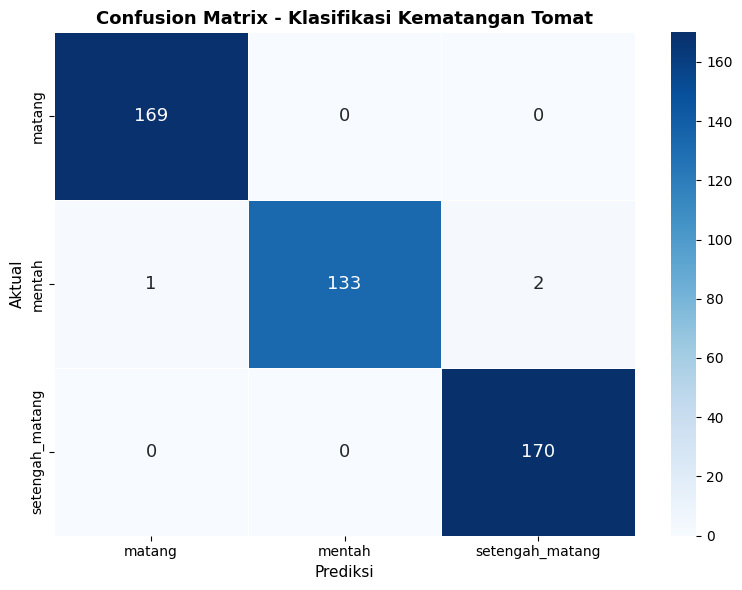

In [16]:
cm = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, annot_kws={"size": 13})
ax.set_title('Confusion Matrix - Klasifikasi Kematangan Tomat', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('Aktual', fontsize=11)
ax.set_xlabel('Prediksi', fontsize=11)
plt.tight_layout()
plt.savefig("confusion_matrix_eval.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Precision, Recall, F1 per Kelas

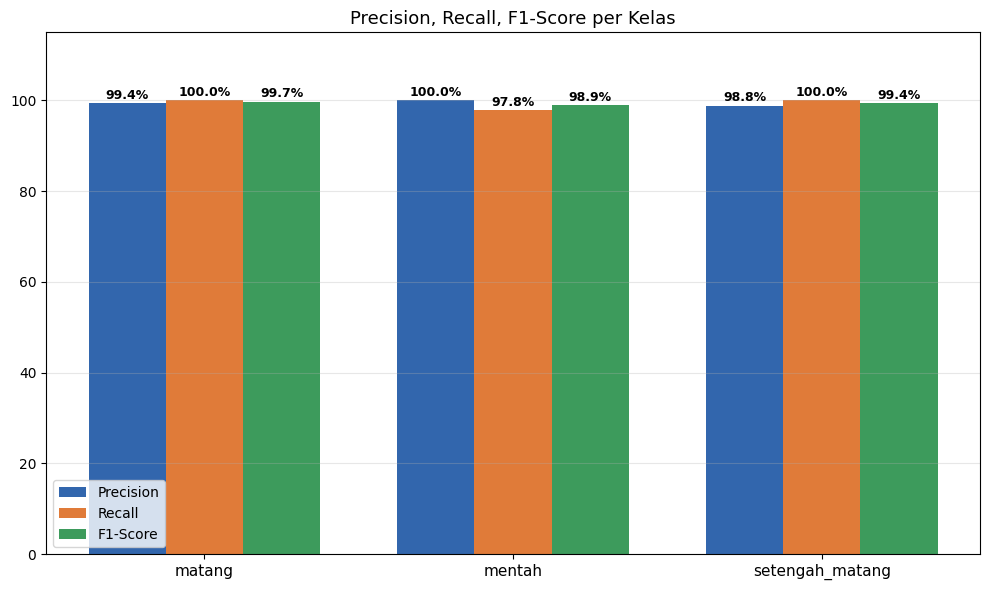

In [17]:
prec_per = precision_score(y, y_pred, average=None)
rec_per  = recall_score(y, y_pred, average=None)
f1_per   = f1_score(y, y_pred, average=None)

x = np.arange(len(CLASS_NAMES))
w = 0.25
fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x-w, prec_per*100, w, label='Precision', color='#3266ad')
b2 = ax.bar(x,   rec_per*100,  w, label='Recall',    color='#e07b39')
b3 = ax.bar(x+w, f1_per*100,   w, label='F1-Score',  color='#3d9b5c')
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+1, 
                f'{h:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Precision, Recall, F1-Score per Kelas', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylim(0, 115)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Classification Report

In [18]:
print(classification_report(y, y_pred, target_names=CLASS_NAMES))

                 precision    recall  f1-score   support

         matang       0.99      1.00      1.00       169
         mentah       1.00      0.98      0.99       136
setengah_matang       0.99      1.00      0.99       170

       accuracy                           0.99       475
      macro avg       0.99      0.99      0.99       475
   weighted avg       0.99      0.99      0.99       475



## 7. Ringkasan Akhir

In [19]:
print(f"{'Kelas':<22} {'Benar':>6} {'Total':>6} {'Akurasi':>10}")
print("-" * 46)
for i, cls in enumerate(CLASS_NAMES):
    total = int(np.sum(y == i))
    benar = int(np.sum((y == i) & (y_pred == i)))
    print(f"{cls:<22} {benar:>6} {total:>6} {benar/total*100:>9.1f}%")
print(f"\nAkurasi keseluruhan : {acc*100:.2f}%")
print(f"Precision weighted  : {prec*100:.2f}%")
print(f"Recall weighted     : {rec*100:.2f}%")
print(f"F1-Score weighted   : {f1*100:.2f}%")

Kelas                   Benar  Total    Akurasi
----------------------------------------------
matang                    169    169     100.0%
mentah                    133    136      97.8%
setengah_matang           170    170     100.0%

Akurasi keseluruhan : 99.37%
Precision weighted  : 99.37%
Recall weighted     : 99.37%
F1-Score weighted   : 99.37%
